# Bayes Rule Notebook
QSCI 497, April 6, 2026

## 1. Review / Helper Material
Bayes Rule is defined as
$$
P(A|B) = \frac{P(B|A) \times P(A)}{P(B)}
$$
Where the notation $P(A)$ refers to the probability of A, and $P(A|B)$ refers to the probability of A given B -- the "|" is pronounced as "given" and denotes a conditional probability. 

Each term in Bayes Rule is defined:
1. $P(A)$ - prior probability, representing our current knowledge
2. $P(B|A)$ - likelihood, representing some observation or prediction
3. $P(A|B)$ - posterior probability, representing our knowledge as improved by some observation

$P(B)$ is the probability of the evidence. For today, it is assumed to be a constant and will be ignored. Therefore Bayes rule is simplified to: 
$$
P(A|B) \propto P(B|A) \times P(A)
$$
### Normalization
It is necessary to normalize all probabilities such that
$$
\int P(x) dx = 1
$$
In other words, the sum of probabilities of all possible outcomes must be equal to 1. 

## 2. Prior PDF
In class I used the historic record of observed hurricane tracks to propose a prior PDF:

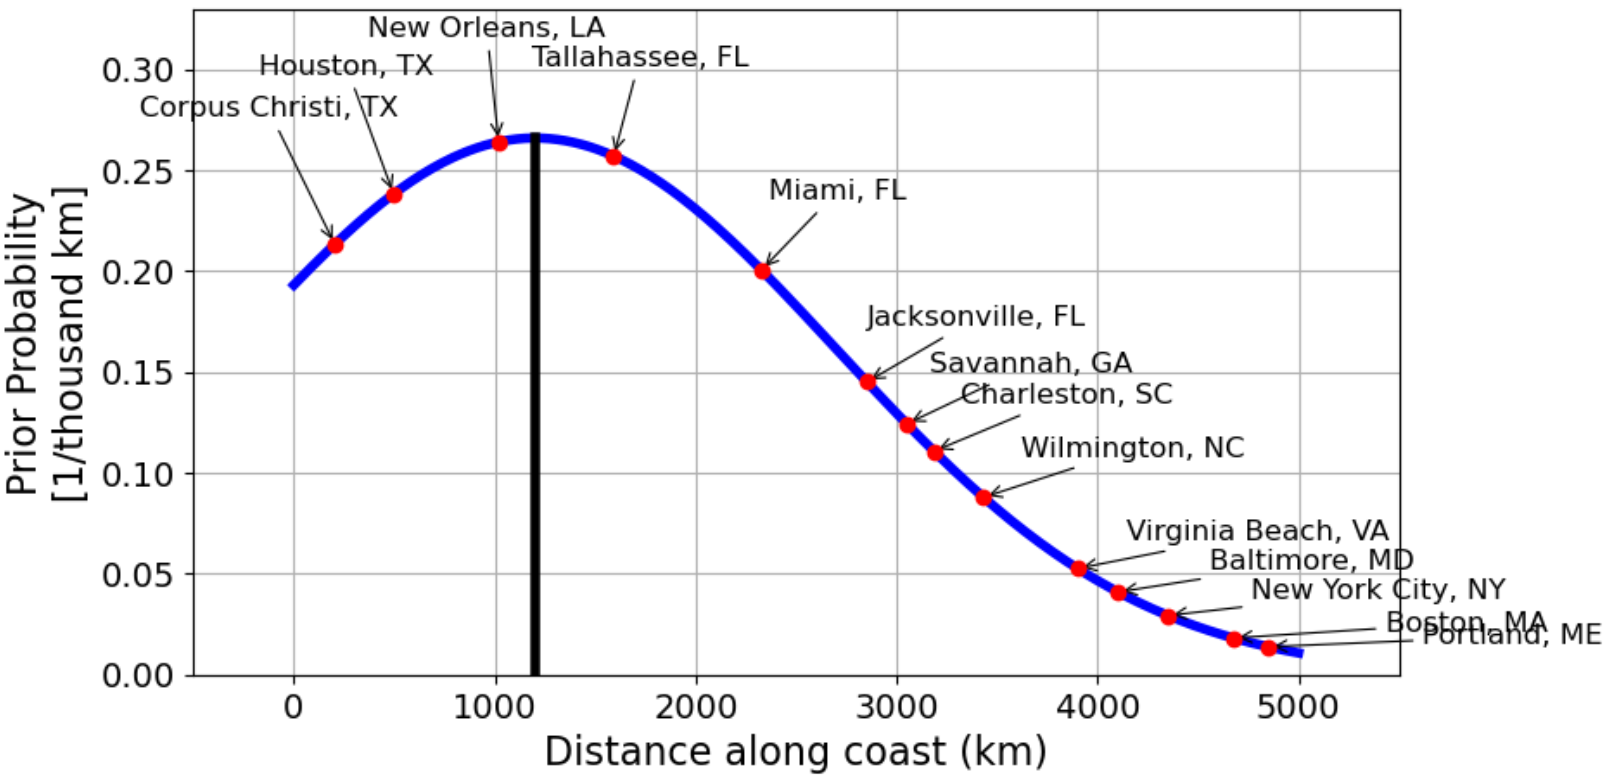

I used a Gaussian probability distribution, defined as
$$
P(x)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$
Where $\mu$ = 1200 km and $\sigma$ = 1500 km. With some location references, that is centered near New Orleans. Let's plot that now:


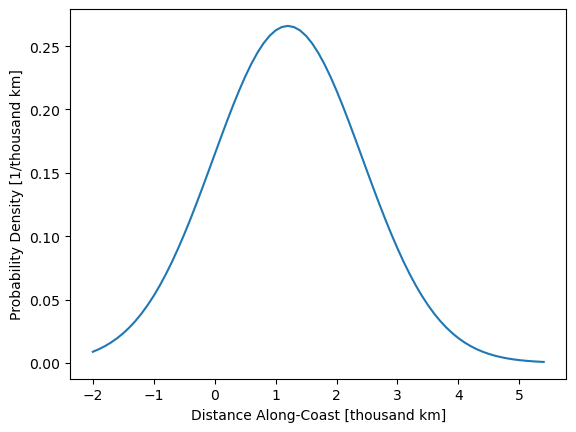

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def gaussian(x, mean, stdev):
    return (1/(stdev*np.sqrt(2*np.pi)))*np.exp(-1*((x - mean)**2)/(2*stdev))

x = np.arange(-2, 5.5, 0.1)
prior = gaussian(x, 1.2, 1.5)

plt.figure()
plt.plot(x, prior)
plt.xlabel("Distance Along-Coast [thousand km]")
plt.ylabel("Probability Density [1/thousand km]")
plt.show()

## 3. Forecast 1: September 28, 2022

Given this pressure map, what is the most likely path for a hurricane to take?

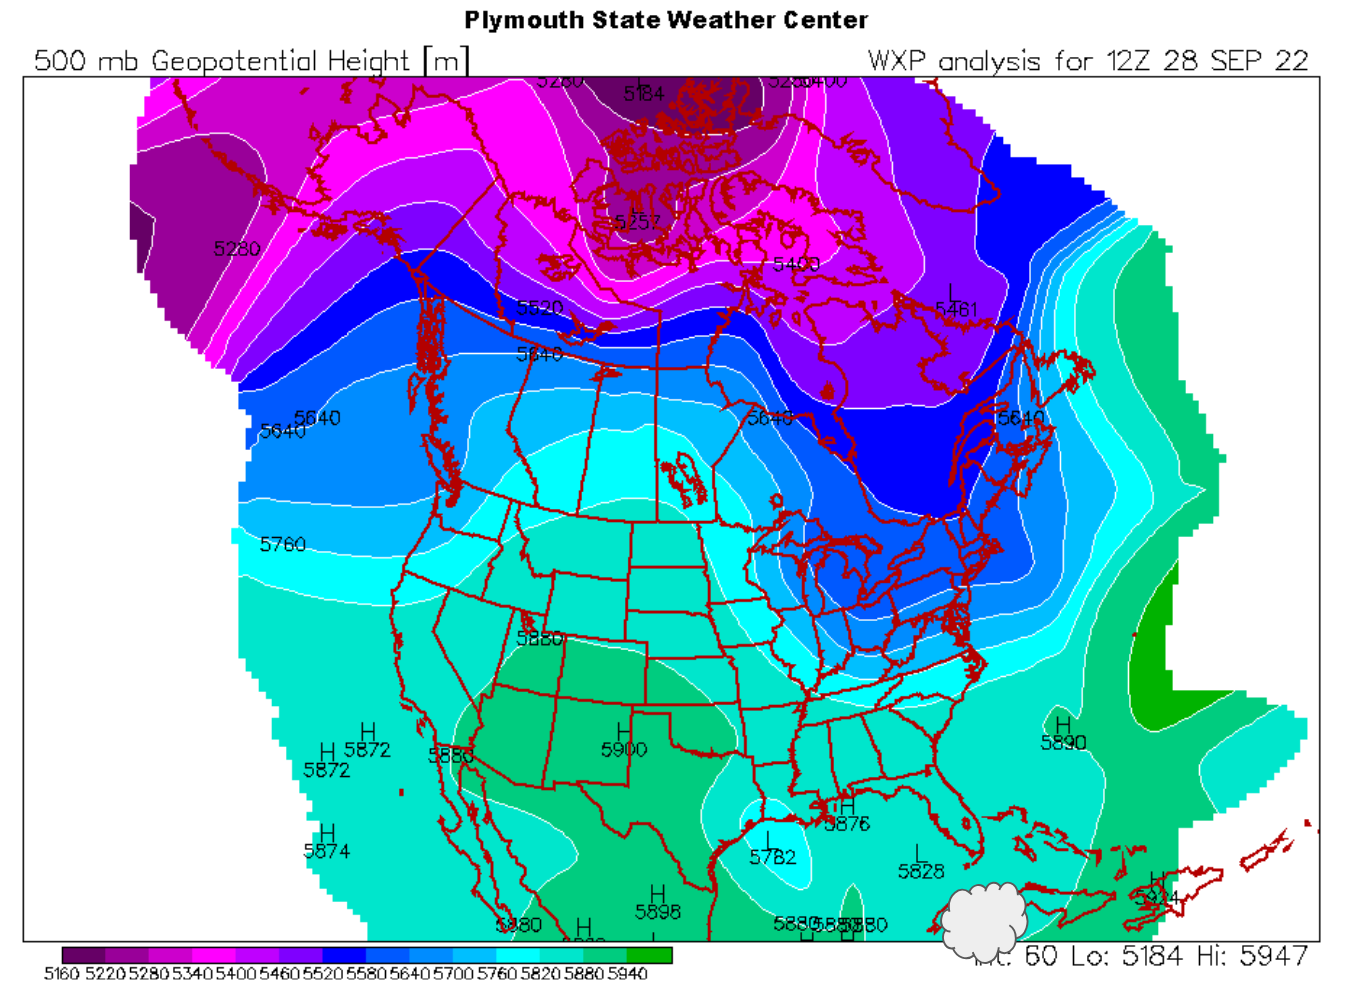

(Plot is the height of the 500 mb contour (which is on average around 5 km high, a representative area for hurricane steering winds) -- high pressure areas means the contour is elevated, and vice versa.)

Interactive forecast diagram: https://scied.ucar.edu/interactive/forecast-hurricane


### Stop: pick a landfall spot first...

In [ ]:
landfall_spot = None 
landfall_deviation = 0.5

likelihood = gaussian(x, landfall_spot, landfall_deviation)

plt.figure()
plt.plot(x, prior, label='Prior')
plt.plot(x, likelihood, label='Likelihood')
plt.legend()
plt.xlabel("Distance Along-Coast [thousand km]")
plt.ylabel("Probability Density [1/thousand km]")
plt.show()

### Computing the Posterior

The posterior is the product of the two PDFs, normalized to 1. Let's start with the product:

In [12]:
posterior = prior * likelihood

To normalized it, we need to make sure the integral adds up to 1. 

In [14]:
posterior_integral = np.trapz(posterior, x=x)
posterior_normed = posterior / posterior_integral

Now let's plot it!

In [ ]:
plt.figure()
plt.plot(x, prior, label='Prior')
plt.plot(x, likelihood, label='Likelihood')
plt.plot(x, posterior_normed, label='Posterior')
plt.legend()
plt.xlabel("Distance Along-Coast [thousand km]")
plt.ylabel("Probability Density [1/thousand km]")
plt.show()

What is the maximum of the posterior? This is the most likely landfall location...

In [ ]:
# Get the index of the max value in the posterior PDF
max_index = np.argmax(posterior)

# Find the distance along-coast that index corresponds to
print(x[max_index])

### What city does this correspond to? 

## 4. Forecast 2: October 27, 2012

Now on your own! With the following pressure map: 

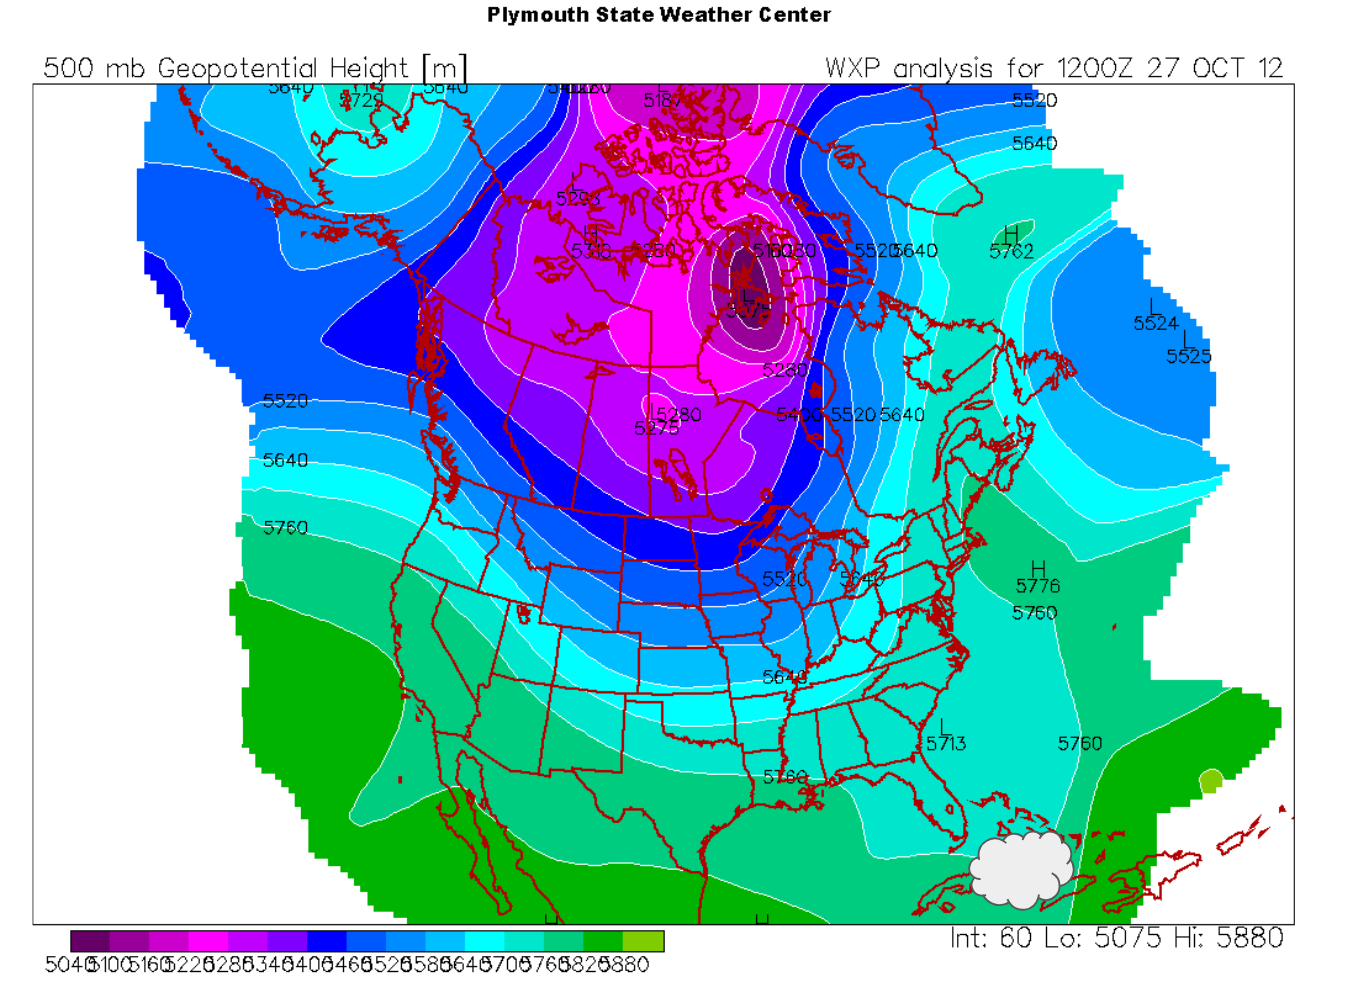

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def gaussian(x, mean, stdev):
    return (1/(stdev*np.sqrt(2*np.pi)))*np.exp(-1*((x - mean)**2)/(2*stdev))

x = np.arange(-2, 5.5, 0.1)
prior = gaussian(x, 1.2, 1.5)

landfall_spot = None 
landfall_deviation = 0.5
likelihood = gaussian(x, landfall_spot, landfall_deviation)

plt.figure()
plt.plot(x, prior, label='Prior')
plt.plot(x, likelihood, label='Likelihood')
plt.legend()
plt.xlabel("Distance Along-Coast [thousand km]")
plt.ylabel("Probability Density [1/thousand km]")
plt.show()

In [ ]:
posterior = prior * likelihood
posterior_integral = np.trapz(posterior, x=x)
posterior_normed = posterior / posterior_integral

In [ ]:
plt.figure()
plt.plot(x, prior, label='Prior')
plt.plot(x, likelihood, label='Likelihood')
plt.plot(x, posterior_normed, label='Posterior')
plt.legend()
plt.xlabel("Distance Along-Coast [thousand km]")
plt.ylabel("Probability Density [1/thousand km]")
plt.show()

In [ ]:
# Get the index of the max value in the posterior PDF
max_index = np.argmax(posterior)
# Find the distance along-coast that index corresponds to
print(x[max_index])

## 5. Bonus Section

The technique you just used is called Maximum a Posteriori (or Bayesian MAP) -- go on google scholar and search "maximum a posteriori + [your subject of interest]" and see what comes up. 

https://scholar.google.com/scholar